# SYNERGY external validation

`reports/wf_ensemble_report.md` action item #2: SYNERGY is an independent systematic-
review screening benchmark ([asreview/synergy-dataset](https://github.com/asreview/synergy-dataset),
CC0, 26 reviews) with inclusion/exclusion decided by each review's own fixed,
pre-registered protocol -- nothing in it is downstream of `academic_research_agent`'s
process. Tests whether `infgrad/Jasper-Token-Compression-600M`, `qwen/qwen3-embedding-8b`,
and `Qwen/Qwen3-Embedding-4B` (the top performers from `wf_embedding_model_bakeoff.ipynb`
and `wf_top_embeddings_generalization.ipynb`) produce a separable space on research
domains and a labelling process this project had no hand in shaping at all, not just on
more `academic_research_agent` exports.

3 reviews picked for a size/difficulty spread: `Sep_2021` (271 rows, 14.8% included --
easiest), `Menon_2022` (975 rows, 7.6%), `van_der_Waal_2022` (1970 rows, 1.7% -- close to
SYNERGY's overall 1.67% rate, the realistic stress test).

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from synergy_dataset import Dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, fbeta_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold

sys.path.insert(0, "../../scripts")
from embedding_utils import embed_papers

CACHE_DIR = Path("../../data/processed/embeddings_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
JASPER = "infgrad/Jasper-Token-Compression-600M"
QWEN8B = "qwen/qwen3-embedding-8b"
QWEN4B = "Qwen/Qwen3-Embedding-4B"
TARGET_MODELS = [LOCAL_MODEL, JASPER, QWEN8B, QWEN4B]

REVIEWS = ["Sep_2021", "Menon_2022", "van_der_Waal_2022"]
N_SPLITS = 5
RANDOM_STATE = 42

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "font.size": 10,
})

## A. Load reviews

In [2]:
reviews = {}
for name in REVIEWS:
    rdf = Dataset(name).to_frame().reset_index().rename(columns={"index": "openalex_id"})
    rdf = rdf.dropna(subset=["title"]).copy()
    rdf["abstract"] = rdf["abstract"].fillna("")
    rdf["y"] = rdf["label_included"].astype(int)
    reviews[name] = rdf
    print(f"{name:20s} {len(rdf):5d} rows, {rdf['y'].sum():4d} included ({rdf['y'].mean():.1%})")

Sep_2021               271 rows,   40 included (14.8%)


Menon_2022             975 rows,   74 included (7.6%)


van_der_Waal_2022     1970 rows,   33 included (1.7%)


## B. Embed each review with local baseline, Jasper, qwen3-8b, qwen3-4b

In [3]:
def _safe_name(model_name):
    return model_name.replace("/", "__").replace(":", "_")


def cached_synergy_vectors(review_name, model_name, titles, abstracts, ids):
    path = CACHE_DIR / f"synergy_{review_name}_{_safe_name(model_name)}_papers.parquet"
    cached_map = {}
    if path.exists():
        cached = pd.read_parquet(path)
        cached_map = dict(zip(cached["id"], cached["embedding"]))

    missing_idx = [i for i, pid in enumerate(ids) if pid not in cached_map]
    if missing_idx:
        print(f"  {review_name} / {model_name}: embedding {len(missing_idx)}/{len(ids)} missing papers ...")
        new_vectors, elapsed = embed_papers(model_name, [titles[i] for i in missing_idx], [abstracts[i] for i in missing_idx])
        print(f"    done in {elapsed:.1f}s")
        for i, vec in zip(missing_idx, new_vectors):
            cached_map[ids[i]] = vec.tolist()
        pd.DataFrame({"id": list(cached_map.keys()), "embedding": list(cached_map.values())}).to_parquet(path)
    else:
        print(f"  {review_name} / {model_name}: all {len(ids)} papers already cached")

    return np.array([cached_map[pid] for pid in ids])


vectors_by_review_model = {}
for review_name, rdf in reviews.items():
    titles, abstracts, ids = rdf["title"].tolist(), rdf["abstract"].tolist(), rdf["openalex_id"].tolist()
    for model_name in TARGET_MODELS:
        vectors_by_review_model[(review_name, model_name)] = cached_synergy_vectors(
            review_name, model_name, titles, abstracts, ids
        )

  Sep_2021 / sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2: all 271 papers already cached
  Sep_2021 / infgrad/Jasper-Token-Compression-600M: all 271 papers already cached
  Sep_2021 / qwen/qwen3-embedding-8b: all 271 papers already cached
  Sep_2021 / Qwen/Qwen3-Embedding-4B: embedding 271/271 missing papers ...


    done in 66.5s
  Menon_2022 / sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2: all 975 papers already cached
  Menon_2022 / infgrad/Jasper-Token-Compression-600M: all 975 papers already cached
  Menon_2022 / qwen/qwen3-embedding-8b: all 975 papers already cached
  Menon_2022 / Qwen/Qwen3-Embedding-4B: embedding 975/975 missing papers ...


    done in 138.0s


  van_der_Waal_2022 / sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2: all 1970 papers already cached
  van_der_Waal_2022 / infgrad/Jasper-Token-Compression-600M: all 1970 papers already cached


  van_der_Waal_2022 / qwen/qwen3-embedding-8b: all 1970 papers already cached
  van_der_Waal_2022 / Qwen/Qwen3-Embedding-4B: embedding 1970/1970 missing papers ...


    done in 285.9s


## C. Within-review cross-validated metrics

In [4]:
def recall_at_k_pct(y_true, proba, k_pct):
    n_pos = y_true.sum()
    if n_pos == 0:
        return np.nan
    k = max(1, int(round(len(y_true) * k_pct)))
    top_k = np.argsort(-proba)[:k]
    return y_true[top_k].sum() / n_pos


K_PCTS = [0.10, 0.20, 0.30]


def metric_bundle(y_true, proba):
    out = {
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
        "f2": fbeta_score(y_true, (proba >= 0.5).astype(int), beta=2, zero_division=0),
        "brier": brier_score_loss(y_true, proba),
    }
    for k_pct in K_PCTS:
        out[f"recall@{int(k_pct * 100)}%"] = recall_at_k_pct(y_true, proba, k_pct)
    return out


def oof_predict(X, y, n_splits, random_state):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    proba = np.full(len(y), np.nan)
    for train_idx, test_idx in skf.split(X, y):
        clf = LogisticRegression(class_weight="balanced", max_iter=1000)
        clf.fit(X[train_idx], y[train_idx])
        proba[test_idx] = clf.predict_proba(X[test_idx])[:, list(clf.classes_).index(1)]
    return proba


results = []
for review_name, rdf in reviews.items():
    y = rdf["y"].to_numpy()
    for model_name in TARGET_MODELS:
        X = vectors_by_review_model[(review_name, model_name)].astype(float)
        n_splits = min(N_SPLITS, int(y.sum()), int((1 - y).sum()))
        oof_proba = oof_predict(X, y, n_splits, RANDOM_STATE)
        m = metric_bundle(y, oof_proba)
        results.append({"review": review_name, "model": model_name, "n_splits": n_splits, **m})
        print(f"{review_name:20s} {model_name:45s} roc_auc={m['roc_auc']:.3f}  pr_auc={m['pr_auc']:.3f}  "
              f"recall@20%={m['recall@20%']:.3f}")

results_df = pd.DataFrame(results)

Sep_2021             sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2 roc_auc=0.706  pr_auc=0.289  recall@20%=0.400
Sep_2021             infgrad/Jasper-Token-Compression-600M         roc_auc=0.743  pr_auc=0.425  recall@20%=0.475


Sep_2021             qwen/qwen3-embedding-8b                       roc_auc=0.769  pr_auc=0.468  recall@20%=0.550
Sep_2021             Qwen/Qwen3-Embedding-4B                       roc_auc=0.761  pr_auc=0.442  recall@20%=0.525
Menon_2022           sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2 roc_auc=0.927  pr_auc=0.551  recall@20%=0.865


Menon_2022           infgrad/Jasper-Token-Compression-600M         roc_auc=0.954  pr_auc=0.761  recall@20%=0.919


Menon_2022           qwen/qwen3-embedding-8b                       roc_auc=0.954  pr_auc=0.786  recall@20%=0.878


Menon_2022           Qwen/Qwen3-Embedding-4B                       roc_auc=0.957  pr_auc=0.791  recall@20%=0.919
van_der_Waal_2022    sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2 roc_auc=0.915  pr_auc=0.213  recall@20%=0.909


van_der_Waal_2022    infgrad/Jasper-Token-Compression-600M         roc_auc=0.964  pr_auc=0.371  recall@20%=0.970


van_der_Waal_2022    qwen/qwen3-embedding-8b                       roc_auc=0.968  pr_auc=0.315  recall@20%=1.000


van_der_Waal_2022    Qwen/Qwen3-Embedding-4B                       roc_auc=0.970  pr_auc=0.338  recall@20%=1.000


## D. Summary + chart

In [5]:
print(results_df.round(3).to_string(index=False))

           review                                                       model  n_splits  roc_auc  pr_auc    f2  brier  recall@10%  recall@20%  recall@30%
         Sep_2021 sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2         5    0.706   0.289 0.390  0.158       0.250       0.400       0.575
         Sep_2021                       infgrad/Jasper-Token-Compression-600M         5    0.743   0.425 0.459  0.194       0.300       0.475       0.575
         Sep_2021                                     qwen/qwen3-embedding-8b         5    0.769   0.468 0.498  0.180       0.375       0.550       0.625
         Sep_2021                                     Qwen/Qwen3-Embedding-4B         5    0.761   0.442 0.457  0.180       0.275       0.525       0.625
       Menon_2022 sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2         5    0.927   0.551 0.649  0.068       0.622       0.865       0.919
       Menon_2022                       infgrad/Jasper-Token-Compression-600

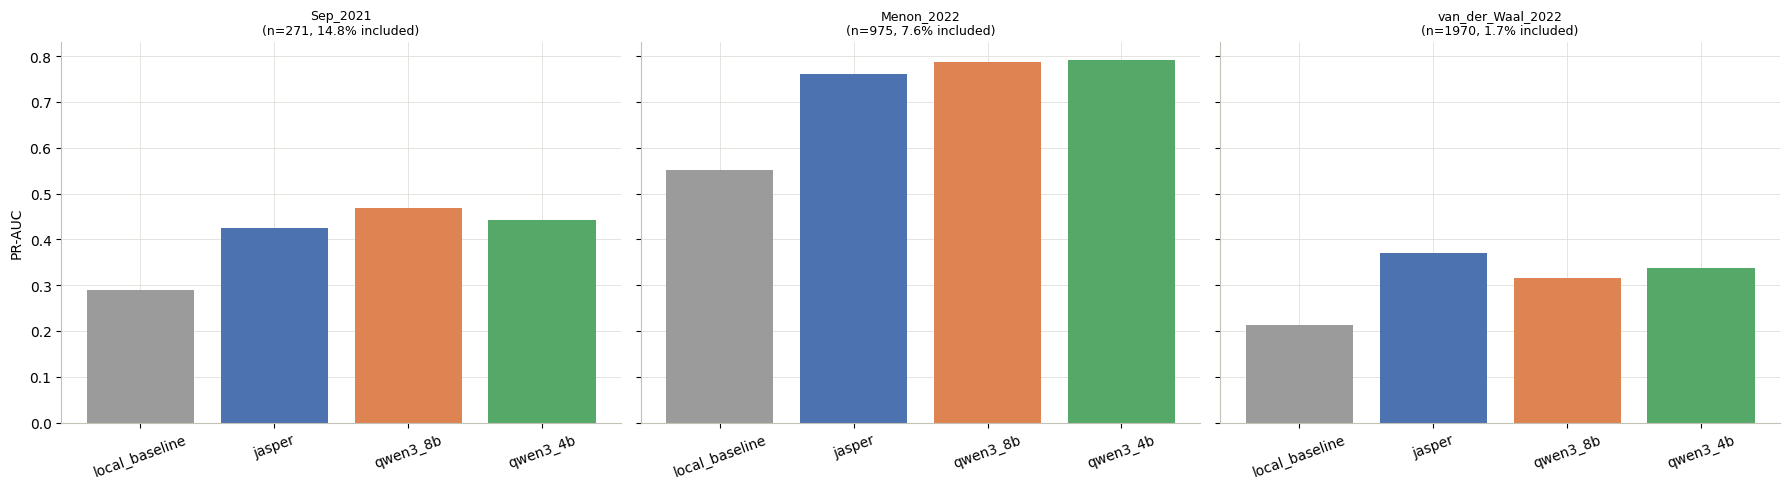

In [6]:
fig, axes = plt.subplots(1, len(REVIEWS), figsize=(6 * len(REVIEWS), 5), sharey=True)
colors = {LOCAL_MODEL: "#9b9b9b", JASPER: "#4c72b0", QWEN8B: "#dd8452", QWEN4B: "#55a868"}
short = {LOCAL_MODEL: "local_baseline", JASPER: "jasper", QWEN8B: "qwen3_8b", QWEN4B: "qwen3_4b"}
for ax, review_name in zip(axes, REVIEWS):
    sub = results_df[results_df.review == review_name]
    ax.bar([short[m] for m in sub["model"]], sub["pr_auc"], color=[colors[m] for m in sub["model"]])
    incl_rate = reviews[review_name]["y"].mean()
    ax.set_title(f"{review_name}\n(n={len(reviews[review_name])}, {incl_rate:.1%} included)", fontsize=9)
    ax.set_ylabel("PR-AUC" if review_name == REVIEWS[0] else "")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## Findings

In [7]:
print("PR-AUC by model, averaged across the 3 SYNERGY reviews:")
print(results_df.groupby("model")["pr_auc"].mean().round(3).sort_values(ascending=False).to_string())
print()
print("For reference, TIRI's own 6-use-case dev-pool PR-AUC (wf_embedding_model_bakeoff.ipynb):")
print("  local_baseline: 0.833   jasper: 0.867   qwen3_8b: 0.891   qwen3_4b: 0.892")
print()
print("Recall@20% by model, averaged across the 3 SYNERGY reviews (most informative metric")
print("given SYNERGY's low inclusion rates, per wf_ensemble_report.md sec 2):")
print(results_df.groupby("model")["recall@20%"].mean().round(3).sort_values(ascending=False).to_string())

PR-AUC by model, averaged across the 3 SYNERGY reviews:
model
Qwen/Qwen3-Embedding-4B                                        0.523
qwen/qwen3-embedding-8b                                        0.523
infgrad/Jasper-Token-Compression-600M                          0.519
sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2    0.351

For reference, TIRI's own 6-use-case dev-pool PR-AUC (wf_embedding_model_bakeoff.ipynb):
  local_baseline: 0.833   jasper: 0.867   qwen3_8b: 0.891   qwen3_4b: 0.892

Recall@20% by model, averaged across the 3 SYNERGY reviews (most informative metric
given SYNERGY's low inclusion rates, per wf_ensemble_report.md sec 2):
model
Qwen/Qwen3-Embedding-4B                                        0.815
qwen/qwen3-embedding-8b                                        0.809
infgrad/Jasper-Token-Compression-600M                          0.788
sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2    0.725
